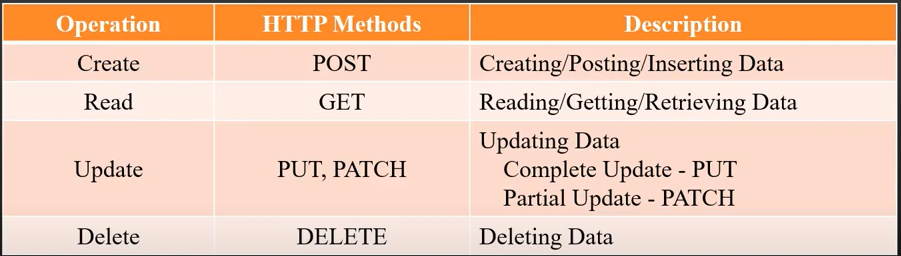

# Python JSON

Python has a built in package called json, which is used to work with json data.
- `dumps(data)` - This is used to convert python object into json string.
- `loads(data)` - This is used to parse json string.

In [1]:
import json

python_data = {'name': 'Sonam', 'roll':101}

json_data = json.dumps(python_data) # return json string

print(json_data)

print(type(json_data))

{"name": "Sonam", "roll": 101}
<class 'str'>


In [2]:
import json

parsed_data = json.loads(json_data) # python object

print(parsed_data)
print(type(parsed_data))

{'name': 'Sonam', 'roll': 101}
<class 'dict'>


# Serializer

In Django REST Framework, serializers are responsible for converting complex data such as querysets and model instances to native Python datatypes (called serialization) that can then be easily rendered into JSON, XML or other content types which is
understandable by Front End.

Serializers are also responsible for deserialization which means it allows parsed data to be converted back into complex types, after first validating the incoming data.

**Think of a Serializer as a translator between complex Python objects (like Django models) and JSON (or XML) that can be sent over the internet via an API.**

A serializer class is very similar to a `Django Form` and `ModelForm` class, and includes similar validation flags on the various fields, such as `required`, `max_length` and `default`.

DRF provides a `Serializer` class which gives you a powerful, generic way to control the output of your responses, as well as a `ModelSerializer` class which provides a useful shortcut for creating serializers that deal with model instances and querysets.

**Why do we need Serializers?**
    
When building APIs, you need to:

1. Send data to the frontend (like a mobile app or a React/Vue app) → Convert Python objects to JSON → Serialization
2. Receive data from the frontend (like a POST request) → Convert JSON to Python objects → Deserialization

**Types of Serializers**
1. Serializer (manual fields)
2. ModelSerializer (automatically generates fields from a Django model)
<br>

**Example 1: Basic Serializer (Manual Way)**

In [ ]:
# a simple class (not a Django model)
class Book:
    def __init__(self, title, author):
        self.title = title
        self.author = author


Here’s how you’d create a serializer for it:

In [ ]:
from rest_framework import serializers

class BookSerializer(serializers.Serializer):
    title = serializers.CharField(max_length=100)
    author = serializers.CharField(max_length=100)


Now let's use it:

In [ ]:
book = Book(title='Django Deep Dive', author='John Doe')

# Serialize the object to JSON-like data
serializer = BookSerializer(book)
print(serializer.data)
# Output: {'title': 'Django Deep Dive', 'author': 'John Doe'}

# Deserialize data (e.g. from frontend)
data = {'title': 'DRF Guide', 'author': 'Jane Doe'}
serializer = BookSerializer(data=data)

if serializer.is_valid():
    validated_data = serializer.validated_data
    print(validated_data)
    # Output: {'title': 'DRF Guide', 'author': 'Jane Doe'}


## How to Create Serializer Class

- Create a separate `serializers.py` file to write all serializers.

<code>
    from rest_framework import serializers
    class StudentSerializer(serializers.Serializer):
        name = serializers.CharField(max_length=100)
        roll = serializers.IntegerField()
        city = serializers.CharField(max_length=100)
</code>

<br>

**Remark:** Generally class name is named as model name i.e. `<ModelNameSerialzer>`

## Serialization

The process of converting complex data such as querysets and model instances to native Python datatypes are called as Serialization in DRF.

**Serialization = Converting Python objects (like Django model instances or querysets) into JSON format so that it can be sent to the frontend or client through an API.**

**🧠 Why do we need it?**

Imagine you have a Django model object (like a Student), and you want to send its data to a frontend app (React, Angular, etc.) or another service via API. The browser or client doesn’t understand Python, but it does understand JSON. So we use serialization to convert `Python → JSON`.


<br>



- Creating model instance stu <code> stu = Student.objects.get(id = 1) </code>
- Converting model instance stu to Python Dict / Serializing Object <code>serializer =  StudentSerializer(stu) </code>


- Creating QuerySet <code> stu = Student.objects.all() </code>
- Converting QuerySet stu to List of Python Dict / Serializing Query Set
<code> serializer = StudentSerializer(stu, many=True) </code>

<br>

- `serializer.data` gives data in serializer (Returns Python `dict` or `list of dicts`).

- `JSONRenderer` is used to render Serialized data into JSON which is understandable by Front End.



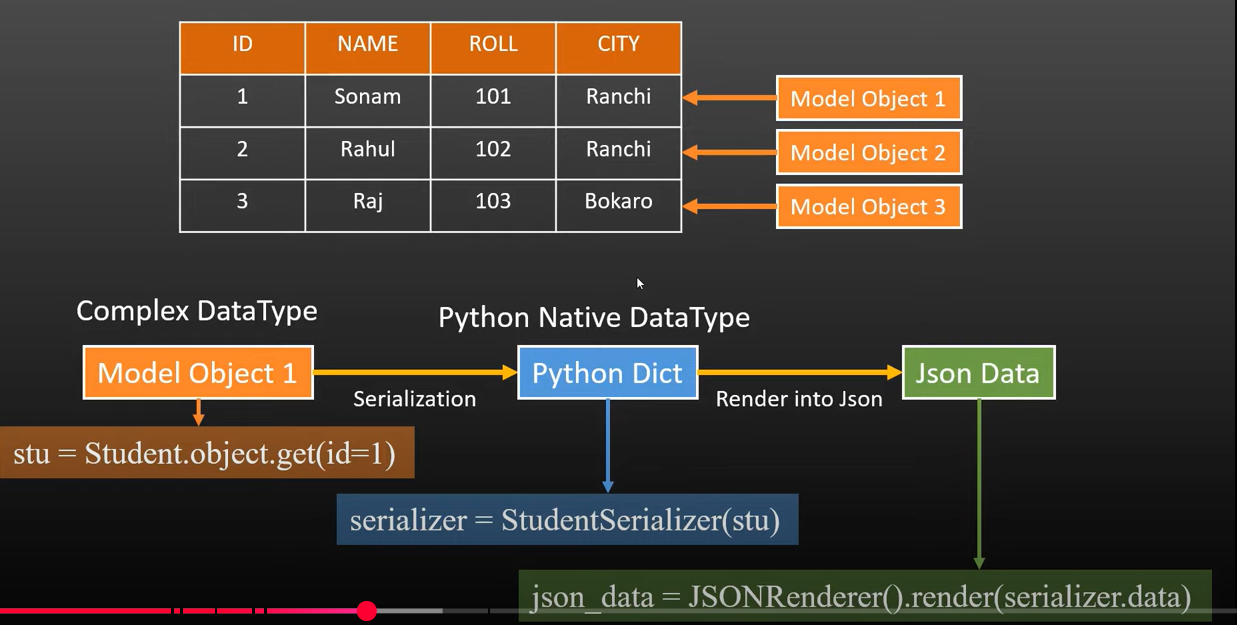


In [ ]:
# rest_project/settings.py:

INSTALLED_APPS = [
    "django.contrib.admin",
    "django.contrib.auth",
    "django.contrib.contenttypes",
    "django.contrib.sessions",
    "django.contrib.messages",
    "django.contrib.staticfiles",
    "rest_framework", # should be added to use DRF
    "api", # app name
]    

In [ ]:
# api/models.py:

from django.db import models

# Create your models here.
class Student(models.Model):
    name = models.CharField(max_length=100)
    roll = models.IntegerField()
    city = models.CharField(max_length=100)

In [ ]:
# api/admin.py:

from django.contrib import admin
from .models import Student

# Register your models here.
@admin.register(Student)
class StudentAdmin(admin.ModelAdmin):
    list_display = ['id', 'name', 'roll', 'city']

In [ ]:
# api/serializers.py:

from rest_framework import serializers

class StudentSerializer(serializers.Serializer):
    id = serializers.IntegerField() # if not specified then id can not be seen in response data
    name = serializers.CharField(max_length=100)
    roll = serializers.IntegerField()
    city = serializers.CharField(max_length=100)
    
# OR

# we can do like this:

from rest_framework import serializers
from .models import Student

class StudentSerializer(serializers.ModelSerializer):
    class Meta:
        model = Student
        fields = ['id', 'name', 'roll', 'city']


In [ ]:
# api/views.py:

from django.shortcuts import render

from .models import Student
from .serializers import StudentSerializer
from rest_framework.renderers import JSONRenderer
from django.http import HttpResponse

# Create your views here.

# Model Object - Single Student Data
def student_detail(request, pk) :
    stu = Student.objects.get(id=pk)  # 🔁 Fetch a single student instance (complex data - model instance)
    serializer = StudentSerializer(stu)  # ✅ Serialize the model instance into Python native data type (dict)
    json_data = JSONRenderer().render(serializer.data)  # ✅ Render Python dict to JSON

    return HttpResponse(json_data, content_type='application/json')  # ✅ Send as HTTP response

# Queryset - All Student Data
def student_list(request) :
    stu = Student.objects.all()  # 🔁 Fetch all students (complex data - queryset)
    serializer = StudentSerializer(stu, many=True)  # ✅ Serialize the queryset into Python list of dicts
    json_data = JSONRenderer().render(serializer.data)  # ✅ Convert the list of dicts to JSON

    return HttpResponse(json_data, content_type='application/json')  # ✅ Send as JSON response

**Key element explanation in above `views.py`:**

- `serializer.data` gives data in serializer (Returns Python `dict` or `list of dicts`).
- `JSONRenderer` is used to render Serialized data into JSON which is understandable by Front End.
- `StudentSerializer(stu)` will return a dict and we can access it through `serializer.data`. It contains data like this:
<code>
{
    'id': 1,
    'name': 'Raj',
    'roll': 101,
    'city': 'Delhi'
}
</code>


- `StudentSerializer(stu, many=True)`will return a list of dictionaries(that's why `many=True`) and we can acess it through `serializer.data`. It contains data like this::
<code>
[
    {'id': 1, 'name': 'Raj', 'roll': 101, 'city': 'Delhi'},
    {'id': 2, 'name': 'Simran', 'roll': 102, 'city': 'Mumbai'},
    {'id': 3, 'name': 'Aman', 'roll': 103, 'city': 'Pune'},
]
</code>



In [ ]:
# api/urls.py:

from django.urls import path
from . import views

urlpatterns = [
    path('stuinfo/<int:pk>', views.student_detail, name = "student_info"),
    path('stuinfo/', views.student_list, name = "all_student_info"),
]

In [ ]:
# rest_project/urls.py:

from django.contrib import admin
from django.urls import path, include

urlpatterns = [
    path("admin/", admin.site.urls),
    path("", include("api.urls")),
]


Now let's look at realword scenario where how an app or third party use our API.

Let's say we have a third party app (python app) `third_party_app.py` and this app want to acess data then it will communicate with our api in order to get data:

In [ ]:
# third_party_app.py

import requests

# URL of your Django API
url = "http://127.0.0.1:8000/stuinfo/"

try:
    # Send GET request
    response = requests.get(url)

    # Raise an error if the request was unsuccessful (status_code != 200)
    response.raise_for_status()

    # Parse JSON response into Python dictionary or list
    data = response.json()

    # Print the parsed data
    print("Data received from API:")
    print(data)

except requests.exceptions.RequestException as e:
    print("An error occurred:", e)


**🔄 Real-World Analogy**
    
Imagine your Django server is a restaurant (API server), and `third_party_app.py` is a customer.

1. The customer (your Python script) makes a request: “Give me all food data.”
2. The restaurant (Django view) responds with a plate of JSON food.
3. The customer receives it and converts it into something they can digest (Python object).

**We can also use `JsonResponse`:**

In [ ]:
# api/views.py:

from django.shortcuts import render

from .models import Student
from .serializers import StudentSerializer
from rest_framework.renderers import JSONRenderer
from django.http import HttpResponse, JsonResponse

# Create your views here.

# Model Object - Single Student Data
def student_detail(request, pk) :
    stu = Student.objects.get(id = pk) # complex data
    serializer = StudentSerializer(stu) # complex data converted into python object
    
    return JsonResponse(serializer.data) # by default safe=True 
    # here serializer.data is dict

# Queryset - All Student Data
def student_list(request) :
    stu = Student.objects.all() # complex data
    serializer = StudentSerializer(stu, many=True) # complex data converted into python object
    
    return JsonResponse(serializer.data, safe=False) # here serializer.data is non-dict

    # By default, JsonResponse() only accepts dictionaries.
    # Since serializer.data returns a list (when many=True), we must set safe=False.

If we don't make `safe=False` then we will get an error: `TypeError at /stuinfo/
In order to allow non-dict objects to be serialized set the safe parameter to False.`

<br>

**We can improve above code by handling exceptions that may occur:**

In [ ]:
from django.http import JsonResponse
from django.core.exceptions import ObjectDoesNotExist
from .models import Student
from .serializers import StudentSerializer
from django.db import DatabaseError


# Get a single student's data by ID and return JSON response
def student_detail(request, pk):
    try:
        student = Student.objects.get(id=pk)  # Get single student (model instance)
    except ObjectDoesNotExist:
        return JsonResponse({'error': 'Student not found'}, status=404)
    
    serializer = StudentSerializer(student)  # Serialize to Python dict
    return JsonResponse(serializer.data, safe=False)  # Return JSON response

# Get all students' data and return JSON response
def student_list(request):
    try:
        students = Student.objects.all()  # Get all student records (queryset)
        serializer = StudentSerializer(students, many=True)  # Serialize queryset to list of dicts
        return JsonResponse(serializer.data, safe=False)  # Return JSON response
    except DatabaseError:
        return JsonResponse({'error': 'Database connection error'}, status=500)

If you have noticed that all of above examples we have not handle GET, POST request i.e, `if request.method == 'GET'` then do this, `if request.method == 'POST'` then do that. This because we're using standard Django views:
- You return JsonResponse
- You don't use @api_view
- You don't explicitly check request.method because you're assuming only GET requests

**This is fine if:**
- You're only supporting a single method (like GET)
- You're not leveraging DRF features (like Request, Response, content negotiation, serializers for input validation)



<br>

**Infact we can do one more thing or even better approach: `Response` objects directly from Django REST Framework, which automatically handles content type and status codes based on the serializer data.**

In [ ]:
# api/views.py:

from django.shortcuts import render

from .models import Student
from .serializers import StudentSerializer
from rest_framework.renderers import JSONRenderer
from django.http import HttpResponse, JsonResponse

from rest_framework.response import Response
from rest_framework.decorators import api_view
from rest_framework import status

# Create your views here.

# Model Object - Single Student Data
@api_view(['GET'])  # 👈 This view supports GET 
def student_detail(request, pk) :
    try:
        stu = Student.objects.get(id = pk) # complex data
        serializer = StudentSerializer(stu) # complex data converted into python object
        return Response(serializer.data) # DRF handles JSON conversion automatically
    except Student.DoesNotExist:
        return Response({'error': 'Student not found'}, status=404)

# Queryset - All Student Data
@api_view(['GET'])  # 👈 This view supports GET 
def student_list(request):
    try:
        stu = Student.objects.all()
        if not stu.exists():
            return Response({"message": "No students found"}, status=status.HTTP_404_NOT_FOUND)
            # OR
            return Response([], status=status.HTTP_200_OK)
            
        serializer = StudentSerializer(stu, many=True)
        return Response(serializer.data, status=status.HTTP_200_OK)

    except Exception as e:  # Catching any unexpected errors
        return Response({"error": str(e)}, status=status.HTTP_500_INTERNAL_SERVER_ERROR)

**NOTE:** In REST APIs, an empty list is not an error — it just means no data. So `200 OK` is usually preferred even if no students are found.

Or you can skip the check altogether that is: 
<code>
if not stu.exists():
    return Response([], status=status.HTTP_200_OK)
</code>

You can skip above check because DRF will handle it just fine:

In [ ]:
@api_view(['GET'])
def student_list(request):
    try:
        stu = Student.objects.all()
        serializer = StudentSerializer(stu, many=True)
        return Response(serializer.data)
    except Exception as e:
        return Response({"error": str(e)}, status=status.HTTP_500_INTERNAL_SERVER_ERROR)


### What is @api_view?
`@api_view` is a decorator provided by DRF that lets you write function-based views (FBVs) to handle API requests.

It:
- Turns a regular Django view into a REST API view
- Automatically parses request data (`JSON`, `Form`, etc.)
- Allows you to specify allowed HTTP methods like `GET`, `POST`, `PUT`, `DELETE`
- Returns a DRF `Response`, which automatically formats your data as JSON

`@api_view(['GET', 'POST'])` This means this view supports GET and POST

<br>

**Example:**

In [ ]:
from rest_framework.decorators import api_view
from rest_framework.response import Response
from rest_framework import status
from .models import Student
from .serializers import StudentSerializer

@api_view(['GET', 'POST'])  # 👈 This view supports GET and POST
def student_view(request):
    if request.method == 'GET':
        students = Student.objects.all()
        serializer = StudentSerializer(students, many=True)
        return Response(serializer.data)

    elif request.method == 'POST':
        serializer = StudentSerializer(data=request.data)  # request.data contains POSTed JSON
        if serializer.is_valid():
            serializer.save()  # saves new student to DB
            return Response(serializer.data, status=status.HTTP_201_CREATED)
        return Response(serializer.errors, status=status.HTTP_400_BAD_REQUEST)


Use `serializer.errors` only after passing data for validation (i.e., in deserialization) — not when simply serializing model instances. You can only use serializer.errors in deserialization (i.e., when you're validating incoming data, like in `POST`, `PUT`, or `PATCH` requests).

## Deserialization

Serializers are also responsible for deserialization which means it allows parsed data to be converted back into complex types, after first validating the incoming data.

**Deserialization = Converting incoming JSON data → into a Python object (and eventually a Django model instance).**

It’s the reverse of serialization.

**🧠 Why do we need it?**
    
When a client sends data to your API (usually via POST, PUT, PATCH), that data is in JSON. But Django models work with Python objects.

So we need to:
1. Parse that JSON
2. Validate the data
3. Convert it into a Django model object
4. Save it to the database (if valid)

That whole process is deserialization.

In [ ]:
# api/serializers.py

from rest_framework import serializers
from .models import Student

class StudentSerializer(serializers.Serializer):
    id = serializers.IntegerField()
    name = serializers.CharField(max_length=100)
    roll = serializers.IntegerField()
    city = serializers.CharField(max_length=100)
    
    def create(self, validate_data):
        return Student.objects.create(**validate_data)

**What is `create()`? Why?**

When you use `StudentSerializer(data=request.data)` and then call `.save()`, Django REST Framework needs to know how to create a new Student instance from the validated data.

Since you're not using `ModelSerializer`, DRF doesn't know the model logic automatically — so you must define it manually using `create()`.

`create()` tells DRF how to create a new model instance using the data that passed validation.

So `create()` is required when using Serializer for inserting new objects. It's triggered by `.save()` after `.is_valid()` passes.

<br>

**Why we define `update()` in a Serializer?**

When you use a `PUT` or `PATCH` request to update an existing object, Django REST Framework calls `serializer.save()` after validating the data.

But since you’re using a plain `Serializer` (not a `ModelSerializer`), DRF doesn’t know how to update your model instance — so you must define the logic manually using an `update()` method.

In [ ]:
def update(self, instance, validated_data):
    instance.name = validated_data.get('name', instance.name)
    instance.roll = validated_data.get('roll', instance.roll)
    instance.city = validated_data.get('city', instance.city)
    instance.save()
    return instance


**❌ No, delete() is not part of a serializer — it's not needed there.**

Unlike `create()` and `update()`, which are used by the serializer to modify data, deleting a model instance is handled directly in the view, because:

- There's no need to serialize data when you're deleting it.- 
- The serializer doesn't know what logic you want for deletion (like checking permissions, logging, etc.).

Here is sample code:

In [ ]:
# views.py:

from rest_framework.decorators import api_view
from rest_framework.response import Response
from rest_framework import status
from .models import Student

@api_view(['DELETE'])
def delete_student(request, pk):
    try:
        student = Student.objects.get(id=pk)
        student.delete()
        return Response({'message': 'Student deleted'}, status=status.HTTP_204_NO_CONTENT)
    except Student.DoesNotExist:
        return Response({'error': 'Student not found'}, status=status.HTTP_404_NOT_FOUND)


**Important Remark:** If you were using `ModelSerializer`, DRF would automatically handle `create()` for you, so you wouldn’t need to define it manually. You can se sample code below:

In [ ]:
# serializers.py:

from rest_framework import serializers
from .models import Student

class StudentSerializer(serializers.ModelSerializer):
    class Meta:
        model = Student
        fields = '__all__'  # Automatically maps model fields
        # fields = ['id', 'name', 'roll', 'city']

    # You can add custom validation to ensure data integrity:
    def validate_age(self, value):
        """Ensure age is a positive number."""
        if value <= 0:
            raise serializers.ValidationError("Age must be greater than zero.")
        return value
    # This Method is automatically invoked when is_valid() method is called


In [ ]:
# views.py:

@api_view(['POST'])
def add_student(request):

    # request.data gets the JSON data sent by client
    serializer = StudentSerializer(data=request.data)  # <--- Deserialization starts here
    # serializer = StudentSerializer(data=request.body)  ❌


    if serializer.is_valid():  # validates the data (checks if required fields, types, formats are correct)
        
        # Accessing validated, cleaned data
        print(serializer.validated_data)

        # creates and saves Student instance in DB
        serializer.save()   # <-- Calls create() and returns the saved Student object

        # serializer.data is Python dictionary ✅
        return Response(serializer.data, status=201) # DRF converts serializer.data to JSON before sending it to the client ✅
        
        # we send message as well in response:
        return Response({'msg': 'data created'}, status=status.HTTP_201_CREATED)
        
    return Response(serializer.errors, status=400)


In [1]:
# what if invalid:

serializer = StudentSerializer(data=request.data)

if not serializer.is_valid():
    print(serializer.errors)  # ➤ shows exactly what went wrong


# Example errors:
{
  "roll": ["This field is required."],
  "city": ["Ensure this field has no more than 50 characters."]
}

**Key element explanation in above `views.py`:**

- Validated Data: `serializer.is_valid()`
- `serializer.validated_data`: gives valided data which we can use for any logic.
- `serializer.errors`: gives error

In [ ]:
# api/urls.py

from django.urls import path
from . import views

urlpatterns = [
    path('stucreate/', views.student_create, name = "student_create"),
]

In [ ]:
# third_party_app.py:

import requests

# API endpoint
url = "http://127.0.0.1:8000/stucreate/"

# Data to be sent in the POST request
data = {
    "name": "rakesh",
    "roll": 105,
    "city": "indore"
}

try:
    # Send POST request with JSON data
    response = requests.post(url, json=data)
    # Use the `json` parameter to automatically handle content-type and serialization

    # Raise exception for HTTP errors
    response.raise_for_status()

    # Parse JSON response
    result = response.json()

    print("Response from API:")
    print(result)

except requests.exceptions.RequestException as e:
    print("An error occurred:", e)


Because we are using the `@api_view` decorator from Django REST Framework (DRF), which by default disables CSRF protection for API views unless explicitly required.

Only worry about CSRF if:
1. You're using Django's standard function-based or class-based views (not DRF) with templates and forms.
2. Or you're accepting POST requests from a frontend running in the browser and using session-based authentication.

**Also instead of `@csrf_exempt`, DRF provides `APIView` and `ViewSet`, which automatically handle CSRF protection only when needed:**

In [ ]:
# using APIView


# api/views.py:

from rest_framework.response import Response
from rest_framework.views import APIView
from rest_framework import status
from .models import Student
from .serializers import StudentSerializer

class StudentCreateAPIView(APIView):
    def post(self, request):
        serializer = StudentSerializer(data=request.data)  # DRF handles JSON parsing
        if serializer.is_valid():
            serializer.save()  # Calls `create()` method in serializer
            return Response(serializer.data, status=status.HTTP_201_CREATED)
        return Response(serializer.errors, status=status.HTTP_400_BAD_REQUEST)

# api/urls.py
from django.urls import path
from .views import StudentCreateAPIView

urlpatterns = [
    path('stucreate/', StudentCreateAPIView.as_view(), name='student-create'),
]


In [ ]:
# using ViewSet

# api/views.py:

from rest_framework import viewsets
from .models import Student
from .serializers import StudentSerializer

class StudentViewSet(viewsets.ModelViewSet):
    queryset = Student.objects.all()  # Fetch all Student objects
    serializer_class = StudentSerializer  # Use the StudentSerializer for data conversion



# api/urls.py
from django.urls import path, include
from rest_framework.routers import DefaultRouter
from .views import StudentViewSet

# Create a router and register the viewset
router = DefaultRouter()
router.register(r'students', StudentViewSet, basename='studentapi')  # The 'students' endpoint will handle CRUD for students

urlpatterns = [
    path('', include(router.urls)),  # Automatically include the URLs for the registered ViewSet
]


Above in code we using DRF for deserialization. What if we want to do it manually that is **manually handling everything — parsing, deserializing, validating, and rendering:**

In [ ]:
# api/views.py

from django.shortcuts import render

from .models import Student
from .serializers import StudentSerializer
from rest_framework.renderers import JSONRenderer
from django.http import HttpResponse, JsonResponse
import io
from rest_framework.parsers import JSONParser
from django.views.decorators.csrf import csrf_exempt

# Create your views here.

@csrf_exempt # Disables CSRF protection for this view
def student_create(request):
    if request.method == 'POST' :
        
        # Step 1: Convert JSON to Python native data
        json_data = request.body
        stream = io.BytesIO(json_data)
        pythondata = JSONParser().parse(stream) #  converts it into a Python dictionary.

        # Step 2: Deserialize JSON data
        serializer = StudentSerializer(data = pythondata)

        # Step 3: Validate and Save
        if serializer.is_valid(): # checks if the data is valid based on the model fields.
            serializer.save() # Saves to DB or creates a new Student object in the database.
            res = {'msg': 'data created'}
            json_data = JSONRenderer().render(res)
            return HttpResponse(json_data, content_type='application/json')
            # We can also use Response() or JSONResponse()
            
        json_data = JSONRenderer().render(serializer.errors)
        return HttpResponse(json_data, content_type='application/json')

        # manually handled everything — parsing, deserializing, validating, and rendering

### What is CSRF  and Why we need to exempt it?

**what is CSRF?**
CSRF stands for Cross-Site Request Forgery. It's a security feature in Django that prevents malicious websites from making unauthorized POST requests to your site using the credentials of an authenticated user (like cookies).

**✅ When does Django enforce CSRF?**
Django enforces CSRF only when:

- You're using session-based authentication (e.g., user logged in via login page and a browser is sending cookies).
- The request method is something that modifies data, like POST, PUT, DELETE.
- The client is a browser, not a script or API client.

**🔐 Example of when CSRF is required:**
Suppose you have a traditional Django view:

In [ ]:
# views.py
from django.views.decorators.csrf import csrf_protect
from django.http import JsonResponse

@csrf_protect # Enables CSRF protection for a view
def create_student(request):
    if request.method == 'POST':
        # logic to save data
        return JsonResponse({'msg': 'Student created'})


If you send a `POST` request from a browser without including a valid CSRF token, Django will block it with a `403 Forbidden error`.

**🧠 But what if you're building an API (like with DRF)?**
When using DRF, the request is usually sent from:

- A mobile app
- A frontend app (like React/Vue)
- A Python script
- A tool like Postman

These clients don't use Django sessions or cookies, so CSRF is irrelevant — and DRF disables it by default.

**🔓 Why do we sometimes say “ensure CSRF is exempted”?**
Because Django enforces CSRF by default for views, unless:

- You use `@csrf_exempt` for regular views.
- You use DRF’s `APIView`, `@api_view`, or `ModelViewSet` — they already exempt CSRF internally.

So when you're not using browser-based session auth, you must make sure CSRF protection doesn't interfere with your API.

If you're not using DRF and you create a normal Django view for an API, you need to manually exempt CSRF using `@csrf_exempt`.

In [ ]:
# ❌ Problematic Example (CSRF enforced):

from django.http import JsonResponse

def my_post_view(request):
    if request.method == 'POST':
        # ❗ Will raise 403 error if CSRF token is missing
        return JsonResponse({'msg': 'Post OK'})


So: `"Ensure CSRF is exempted" means: make sure Django doesn't block your API requests just because they don't come from a browser with a CSRF token.`

In [ ]:
from django.views.decorators.csrf import csrf_exempt
from django.http import HttpResponse

@csrf_exempt # Disables CSRF protection for a specific view
def api_view(request):
    return HttpResponse("CSRF protection is disabled for this view")


## Should we include id in Serializer?

**You typically include id in your serializer when:**

1. You want to return the id in the response. For example, after creating a student, you want the client to know the id of the newly created object.
2. You're using the serializer for both read and write operations.
    - In read operations, the client may want to know the ID.
    - In write (POST/PUT) operations, the ID is usually auto-generated (read-only) or used to update a record.
3. You're doing updates using PUT/PATCH and the client sends the ID.

**You can skip id in fields when:**

1. You’re only creating objects and don’t care about returning the ID in response.
2. You’re creating a serializer for write-only purposes.
3. You don’t want the client to ever see or send the ID (rare in APIs though).

<br>

**Even if you include `id`, it’s usually a good idea to mark it as read-only:**

In [ ]:
# serializers.py:

class StudentSerializer(serializers.ModelSerializer):
    class Meta:
        model = Student
        fields = ['id', 'name', 'roll', 'city']
        read_only_fields = ['id']


This ensures:

- It’s shown in responses.
- It won’t be required/allowed in POST data.



In [ ]:
# serializers.py:

from rest_framework import serializers
from .models import Student

class StudentSerializer(serializers.Serializer):
    id = serializers.IntegerField(read_only=True)  # 🔒 Marking id as read-only
    
    name = serializers.CharField(max_length=100)
    roll = serializers.IntegerField()
    city = serializers.CharField(max_length=100)

    def create(self, validated_data):
        return Student.objects.create(**validated_data)

    def update(self, instance, validated_data):
        instance.name = validated_data.get('name', instance.name)
        instance.roll = validated_data.get('roll', instance.roll)
        instance.city = validated_data.get('city', instance.city)
        instance.save()
        return instance


# CRUD API using Function Based View and Class Based View in Django REST Framework

In [ ]:
# api/models.py

from django.db import models

# Create your models here.
class Student(models.Model) :
    name = models.CharField(max_length=100)
    roll = models.IntegerField()
    city = models.CharField(max_length=100)

In [ ]:
# api/admin.py

from django.contrib import admin
from .models import Student

# Register your models here.
@admin.register(Student)
class StudentAdmin(admin.ModelAdmin):
    list_display = ['id', 'name', 'roll', 'city']

In [ ]:
# api/serializers.py:

from rest_framework import serializers
from .models import Student

class StudentSerializer(serializers.Serializer):
    #id = serializers.IntegerField()
    name = serializers.CharField(max_length=100)
    roll = serializers.IntegerField()
    city = serializers.CharField(max_length=100)
    
    def create(self, validated_data):
        return Student.objects.create(**validated_data)
    
    def update(self, instance, validated_data): 
        instance.name = validated_data.get('name', instance.name)
        instance.roll = validated_data.get('roll', instance.roll)
        instance.city = validated_data.get('city', instance.city)
        instance.save()
        return instance

        # instance is old data stored in DB
        # validated_data is new data from user for updation

# Or we can use ModelSerializer

class StudentSerializer(serializers.ModelSerializer):
    class Meta:
        model = Student
        fields = '__all__'  # Includes all model fields automatically

In [ ]:
# api/urls.py:

from django.urls import path
from . import views

urlpatterns = [  
    path('studentapi/', views.student_api),
]

## Approach 1: manual

In [ ]:
# api/views.py:


from django.shortcuts import render

from .models import Student
from .serializers import StudentSerializer
from rest_framework.renderers import JSONRenderer
from django.http import HttpResponse, JsonResponse
import io
from rest_framework.parsers import JSONParser
from rest_framework.response import Response
from rest_framework.decorators import api_view
from django.views.decorators.csrf import csrf_exempt

# Create your views here.

# creating api to perform CRUD

@csrf_exempt
def student_api(request):
    if request.method == 'GET':
        json_data = request.body
        print(json_data)
        stream = io.BytesIO(json_data)
        print(stream)
        pythondata = JSONParser().parse(stream)
        print(pythondata)
        id = pythondata.get('id', None)
        
        if id is not None:
            stu = Student.objects.get(id = id)
            serializer = StudentSerializer(stu)
            # By default, serializers must be passed values for all required fields or they
            # will raise validation errors.
            
            json_data = JSONRenderer().render(serializer.data)
            return HttpResponse(json_data, content_type='application/json')
        
        stu = Student.objects.all()
        serializer = StudentSerializer(stu, many=True)
        json_data = JSONRenderer().render(serializer.data)
        return HttpResponse(json_data, content_type='application/json')
    
    if request.method == 'POST':
        json_data = request.body
        stream = io.BytesIO(json_data)
        pythondata = JSONParser().parse(stream)
        serializer = StudentSerializer(data = pythondata)
        if serializer.is_valid():
            serializer.save()
            res = {'msg': 'Data Created'}
            json_data = JSONRenderer().render(res)
            return HttpResponse(json_data, content_type='application/json')
        
        json_data = JSONRenderer().render(serializer.errors)
        return HttpResponse(json_data, content_type='application/json')
    
    if request.method == 'PUT':
        json_data= request.body
        stream = io.BytesIO(json_data)
        pythondata = JSONParser().parse(stream)
        id = pythondata.get('id')
        stu = Student.objects.get(id=id)
        serializer = StudentSerializer(stu, data=pythondata, partial=True)
        if serializer.is_valid():
            serializer.save()
            res = {'msg': 'Data Updated !!'}
            json_data = JSONRenderer().render(res)
            return HttpResponse(json_data, content_type='application/json')
        json_data = JSONRenderer().render(serializer.errors)
        return HttpResponse(json_data, content_type='application/json')
    
    if request.method == 'DELETE':
        json_data = request.body
        stream = io.BytesIO(json_data)
        pythondata = JSONParser().parse(stream)
        id = pythondata.get('id')
        stu = Student.objects.get(id=id)
        stu.delete()
        res = {'msg': 'Data Deleted!!'}
        json_data = JSONRenderer().render(res)
        return HttpResponse(json_data, content_type='application/json')

## Approach 2: View class 

In [ ]:
# api/views.py:


from django.shortcuts import render

from .models import Student
from .serializers import StudentSerializer
from rest_framework.renderers import JSONRenderer
from django.http import HttpResponse, JsonResponse
import io
from rest_framework.parsers import JSONParser
from rest_framework.response import Response
from rest_framework.decorators import api_view
from django.views.decorators.csrf import csrf_exempt

from django.utils.decorators import method_decorator
from django.views import View

# Create your views here.

#------------class based views

@method_decorator(csrf_exempt, name="dispatch")
class StudentAPI(View):
    def get(self, request, *args, **kwargs):
        json_data = request.body
        stream = io.BytesIO(json_data)
        pythondata = JSONParser().parse(stream)
        print(pythondata)
        id = pythondata.get('id', None)
        
        if id is not None:
            stu = Student.objects.get(id = id)
            serializer = StudentSerializer(stu)
            json_data = JSONRenderer().render(serializer.data)
            return HttpResponse(json_data, content_type='application/json')
        
        stu = Student.objects.all()
        serializer = StudentSerializer(stu, many=True)
        json_data = JSONRenderer().render(serializer.data)
        return HttpResponse(json_data, content_type='application/json')
    
    def post(self, request, *args, **kwargs):
        json_data = request.body
        stream = io. BytesIO(json_data)
        pythondata = JSONParser().parse(stream)
        serializer = StudentSerializer(data = pythondata)
        if serializer.is_valid():
            serializer.save()
            res = {'msg': 'Data Created'}
            json_data = JSONRenderer().render(res)
            return HttpResponse(json_data, content_type='application/json')
        
        json_data = JSONRenderer().render(serializer.errors)
        return HttpResponse(json_data, content_type='application/json')
    
    def put(self, request, *args, **kwargs):
        json_data= request.body
        stream = io.BytesIO(json_data)
        pythondata = JSONParser().parse(stream)
        id = pythondata.get('id')
        stu = Student.objects.get(id=id)
        serializer = StudentSerializer(stu, data=pythondata, partial=True)
        if serializer.is_valid():
            serializer.save()
            res = {'msg': 'Data Updated !!'}
            json_data = JSONRenderer().render(res)
            return HttpResponse(json_data, content_type='application/json')
        json_data = JSONRenderer().render(serializer.errors)
        return HttpResponse(json_data, content_type='application/json')
    
    def delete(self, request, *args, **kwargs):
        json_data = request.body
        stream = io.BytesIO(json_data)
        pythondata = JSONParser().parse(stream)
        id = pythondata.get('id')
        stu = Student.objects.get(id=id)
        stu.delete()
        res = {'msg': 'Data Deleted!!'}
        json_data = JSONRenderer().render(res)
        return HttpResponse(json_data, content_type='application/json')

In [ ]:
# api/urls.py

from django.urls import path
from . import views

urlpatterns = [
    path('studentapi/', views.StudentAPI.as_view()),
]

## Approach 3: APIView class

- Exception handling (get_object_or_404 instead of try/except)
- Secure request methods without needing @csrf_exempt

In [ ]:
# api/views.py:

from rest_framework.views import APIView
from rest_framework.response import Response
from rest_framework import status
from django.shortcuts import get_object_or_404
from .models import Student
from .serializers import StudentSerializer

class StudentAPIView(APIView):
    def get(self, request):
        student_id = request.GET.get('id')  # Get 'id' from query parameters

        if student_id:
            student = get_object_or_404(Student, id=student_id)
            serializer = StudentSerializer(student)
        else:
            students = Student.objects.all()
            serializer = StudentSerializer(students, many=True)
        
        return Response(serializer.data)

    def post(self, request):
        serializer = StudentSerializer(data=request.data)
        if serializer.is_valid():
            serializer.save()
            return Response({'msg': 'Data Created'}, status=status.HTTP_201_CREATED)
        return Response(serializer.errors, status=status.HTTP_400_BAD_REQUEST)

    def put(self, request):
        student_id = request.data.get('id')
        student = get_object_or_404(Student, id=student_id)

        serializer = StudentSerializer(student, data=request.data, partial=True)
        if serializer.is_valid():
            serializer.save()
            return Response({'msg': 'Data Updated !!'})
        return Response(serializer.errors, status=status.HTTP_400_BAD_REQUEST)

    def delete(self, request):
        student_id = request.data.get('id')
        student = get_object_or_404(Student, id=student_id)
        student.delete()
        return Response({'msg': 'Data Deleted!!'}, status=status.HTTP_204_NO_CONTENT)


## Approach 4: ViewSet class

In [ ]:
# views.py
from rest_framework import viewsets, status
from rest_framework.response import Response
from .models import Student
from .serializers import StudentSerializer

class StudentViewSet(viewsets.ViewSet):
    
    def list(self, request):
        students = Student.objects.all()
        serializer = StudentSerializer(students, many=True)
        return Response(serializer.data)

    def retrieve(self, request, pk=None):
        try:
            student = Student.objects.get(pk=pk)
        except Student.DoesNotExist:
            return Response({"error": "Student not found"}, status=status.HTTP_404_NOT_FOUND)
        serializer = StudentSerializer(student)
        return Response(serializer.data)

    def create(self, request):
        serializer = StudentSerializer(data=request.data)
        if serializer.is_valid():
            serializer.save()  # calls create()
            return Response(serializer.data, status=status.HTTP_201_CREATED)
        return Response(serializer.errors, status=status.HTTP_400_BAD_REQUEST)

    def update(self, request, pk=None):
        try:
            student = Student.objects.get(pk=pk)
        except Student.DoesNotExist:
            return Response({"error": "Student not found"}, status=status.HTTP_404_NOT_FOUND)
        serializer = StudentSerializer(student, data=request.data)
        if serializer.is_valid():
            serializer.save()  # calls update()
            return Response(serializer.data)
        return Response(serializer.errors, status=status.HTTP_400_BAD_REQUEST)

    def destroy(self, request, pk=None):
        try:
            student = Student.objects.get(pk=pk)
        except Student.DoesNotExist:
            return Response({"error": "Student not found"}, status=status.HTTP_404_NOT_FOUND)
        student.delete()
        return Response({"message": "Student deleted successfully"}, status=status.HTTP_204_NO_CONTENT)


In [ ]:
# urls.py
from django.urls import path, include
from rest_framework.routers import DefaultRouter
from .views import StudentViewSet

router = DefaultRouter()
router.register('students', StudentViewSet, basename='student')

urlpatterns = [
    path('', include(router.urls)),
]


## Approach 5: ModelViewSet class

This is the most concise and powerful way to create a full CRUD API using Django REST Framework.

For even less code and automatic URL routing, use `ModelViewSet` and `Router`.

It's recommended to use `ModelSerializer` with `ModelViewSet`:

In [ ]:
# api/serializers.py

from rest_framework import serializers
from .models import Student

class StudentSerializer(serializers.ModelSerializer):
    class Meta:
        model = Student
        fields = ['id', 'name', 'roll', 'city']
        read_only_fields = ['id']  # Optional: ID is auto-generated and not required during creation


In [ ]:
# api/views.py:

from rest_framework import viewsets
from .models import Student
from .serializers import StudentSerializer

class StudentViewSet(viewsets.ModelViewSet):
    queryset = Student.objects.all() # var name should be same
    serializer_class = StudentSerializer # var name should be same


In [ ]:
# urls.py:

from django.urls import path, include
from rest_framework.routers import DefaultRouter
from .views import StudentViewSet

# Create a router and register the StudentViewSet
router = DefaultRouter()
router.register(r'students', StudentViewSet, basename='studentapi')  # This creates routes for CRUD operations on students

# Define URL patterns for the app
urlpatterns = [
    path('', include(router.urls)),  # Include the automatically generated URLs from the router
]

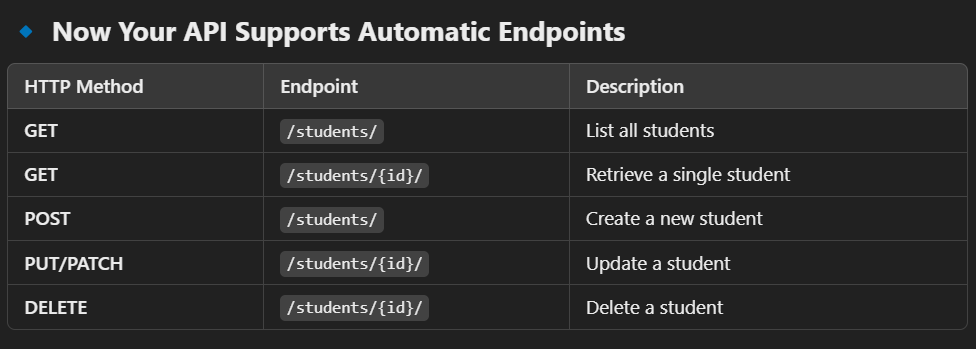

**Why ViewSet is the Best?**
- Automatically handles GET, POST, PUT, DELETE
- No need for id in `request.data` – DRF handles it in URLs
- Clean and minimal code

In [ ]:
# third_party_app.py

import requests

BASE_URL = "http://127.0.0.1:8000"  # Base URL of your API

# Generic GET request function
def get_data(endpoint):
    try:
        response = requests.get(f"{BASE_URL}{endpoint}")
        response.raise_for_status()
        return response.json()
    except requests.exceptions.RequestException as e:
        print("GET request error:", e)
        return None

# Generic POST request function
def post_data(endpoint, data):
    try:
        response = requests.post(f"{BASE_URL}{endpoint}", json=data)
        response.raise_for_status()
        return response.json()
    except requests.exceptions.RequestException as e:
        print("POST request error:", e)
        return None

# Generic PUT request function (for updating)
def put_data(endpoint, data):
    try:
        response = requests.put(f"{BASE_URL}{endpoint}", json=data)
        response.raise_for_status()
        return response.json()
    except requests.exceptions.RequestException as e:
        print("PUT request error:", e)
        return None

# Generic DELETE request function
def delete_data(endpoint):
    try:
        response = requests.delete(f"{BASE_URL}{endpoint}")
        response.raise_for_status()
        return {"msg": "Deleted successfully"} if response.status_code == 204 else response.json()
    except requests.exceptions.RequestException as e:
        print("DELETE request error:", e)
        return None


if __name__ == "__main__":
    # Example GET
    students = get_data("/stuinfo/")
    print("All students:", students)

    # Example POST
    new_student = {
        "name": "Rakesh",
        "roll": 105,
        "city": "Indore"
    }
    result = post_data("/stucreate/", new_student)
    print("Create response:", result)

    # Example PUT (update student with id 1)
    updated_student = {
        "name": "Rakesh Kumar",
        "roll": 105,
        "city": "Bhopal"
    }
    update_response = put_data("/stuupdate/1/", updated_student)
    print("Update response:", update_response)

    # Example DELETE (delete student with id 1)
    delete_response = delete_data("/studelete/1/")
    print("Delete response:", delete_response)


# Validation in DRF

Validation in Django REST Framework (DRF) ensures that the data sent to your API is correct before saving it to the database or processing it further.

In DRF, validation typically happens when you instantiate a serializer with input data and call `.is_valid()`:

In [ ]:
serializer = StudentSerializer(data=request.data)
if serializer.is_valid():
    serializer.save()


**DRF supports 3 main types of validation:**

## Field Level Validation
- We can specify custom field-level validation by adding `validate_fieldName()` methods to your Serializer subclass.
- These are similar to the `clean_fieldName` methods on Django forms.
- `validate_fieldName()` methods should return the validated value or raise a `serializers.ValidationError`

In [ ]:
# api/serializers.py

from rest_framework import serializers
from .models import Student

class StudentSerializer(serializers.Serializer):
    #id = serializers.IntegerField()
    name = serializers.CharField(max_length=100)
    roll = serializers.IntegerField()
    city = serializers.CharField(max_length=100)
    
    def create(self, validate_data):
        return Student.objects.create(**validate_data)
    
    def update(self, instance, validated_data):
        instance.name = validated_data.get('name', instance.name)
        instance.roll = validated_data.get('roll', instance.roll)
        instance.city = validated_data.get('city', instance.city)
        instance.save()
        return instance
    
    # Field Lavel Validation
    def validate_roll(self, value): # should be name as validate_field
        if value >= 200:
            raise serializers.ValidationError('Seat Full')
        return value
    # function will be called by post() of views.py when this line of code is executed: if serializer.is_valid()

## Object Level Validation

When we need to do validation that requires access to multiple fields we do object level validation by adding a method called `validate(self, data)` to Serializer subclass.

- It raises a `serializers.ValidationError` if necessary, or just return the validated values.

In [ ]:
# api/serializers.py

from rest_framework import serializers
from .models import Student

class StudentSerializer(serializers.Serializer):
    #id = serializers.IntegerField()
    name = serializers.CharField(max_length=100)
    roll = serializers.IntegerField()
    city = serializers.CharField(max_length=100)
    
    def create(self, validate_data):
        return Student.objects.create(**validate_data)
    
    def update(self, instance, validated_data):
        instance.name = validated_data.get('name', instance.name)
        instance.roll = validated_data.get('roll', instance.roll)
        instance.city = validated_data.get('city', instance.city)
        instance.save()
        return instance
    
    # Object Level Validation
    def validate(self, data):
        nm = data.get('name')
        ct = data.get('city')
        if nm.lower() == 'rohit' and ct.lower() != 'ranchi' :
            raise serializers.ValidationError('City must be Ranchi')
        return data

## Model-level validation (with ModelSerializer)

Model-level validation in Django REST Framework (DRF) happens when you're using a `ModelSerializer`, and it leverages the validation rules defined inside your Django model class.

**✅ How Model-Level Validation Works**
When you use a ModelSerializer, DRF:

1. Automatically reads field definitions and constraints from your Django model.
2. Performs validation using:
    - Field attributes (`blank=False`, `unique=True`, etc.)
    - Model's `clean()` method (if defined)
    - Model's `clean_<field>()` methods (if defined)
    - Any custom validation you add in the serializer.



In [ ]:
# models.py

from django.db import models
from django.core.exceptions import ValidationError

class Student(models.Model):
    name = models.CharField(max_length=100)
    roll = models.IntegerField(unique=True)
    age = models.IntegerField()

    def clean(self):
        if self.age < 5:
            raise ValidationError("Age must be at least 5 years.")

    def clean_name(self):
        if self.name.lower() == "admin":
            raise ValidationError("Invalid name.")


In [ ]:
# serializers.py

from rest_framework import serializers
from .models import Student

class StudentSerializer(serializers.ModelSerializer):
    class Meta:
        model = Student
        fields = '__all__'


## Validators

Most of the time you're dealing with validation in REST framework you'll simply be relying on the default field validation, or writing explicit validation methods on serializer or field classes.

However, sometimes you'll want to place your validation logic into reusable components, so that it can easily be reused throughout your codebase. This can be achieved by using validator functions and validator classes.

REST framework the validation is performed entirely on the serializer class. This is advantageous for the following reasons:
- It introduces a proper separation of concerns, making your code behavior more obvious.
- It is easy to switch between using shortcut `ModelSerializer` classes and using explicit Serializer classes. Any validation behavior being used for ModelSerializer is simple to eplicate.
- Printing the `repr()` of a serializer instance will show you exactly what validation rules it applies. There's no extra hidden validation behavior being called on the model instance.
- When you're using `ModelSerializer` all of this is handled automatically for you. If you want to drop down to using Serializer classes instead, then you need to define the validation rules explicitly.


In [ ]:
# api/serializers.py

from rest_framework import serializers
from .models import Student

# validators
def start_with_r(value) :
    if value[0].lower() != 'r':
        raise serializers.ValidationError('Name should be start with R')

class StudentSerializer(serializers.Serializer):
    #id = serializers.IntegerField()
    name = serializers.CharField(max_length=100, validators=[start_with_r])
    roll = serializers.IntegerField()
    city = serializers.CharField(max_length=100)
    
    def create(self, validate_data):
        return Student.objects.create(**validate_data)
    
    def update(self, instance, validated_data):
        instance.name = validated_data.get('name', instance.name)
        instance.roll = validated_data.get('roll', instance.roll)
        instance.city = validated_data.get('city', instance.city)
        instance.save()
        return instance
    

**DRF validation flow:**

1. Runs field-level validators.
2. Runs object-level validators.
3. Checks model field constraints (like unique, blank=False).

# ModelSerializer

`ModelSerializer` is a shortcut serializer provided by DRF that automatically generates fields based on a Django model.

It's the recommended way to serialize data when you're working with Django models, as it reduces boilerplate and ensures consistency between your model and serializer.

The ModelSerializer class is the same as a regular Serializer class, except that:
- It will automatically generate a set of fields for you, based on the model.
- It will automatically generate validators for the serializer, such as `unique_together` validators.
- It includes simple default implementations of create and update.

In [ ]:
# api/serializers.py

from rest_framework import serializers
from .models import Student    

class StudentSerializer(serializers.ModelSerializer):
    class Meta:
        model = Student
        fields = ['name', 'roll', 'city']
        
        # fields = '__all__'
        # exclude = ['roll']
        
# OR-----------------------------

class StudentSerializer(serializers.ModelSerializer):
    name = serializers.CharField(read_only=True)
    class Meta:
        model = Student
        fields = ['name', 'roll', 'city']
        
# OR-----------------------------

class StudentSerializer(serializers.ModelSerializer):
    
    class Meta:
        model = Student
        fields = ['name', 'roll', 'city']
        read_only_fields = ['name','roll']
        
# OR-----------------------------

class StudentSerializer(serializers.ModelSerializer):
    
    class Meta:
        model = Student
        fields = ['name', 'roll', 'city']

        extra_kwargs = {'name': {'read_only': True}, 'roll': {'read_only': True}}

In [ ]:
# api/serializers.py

from rest_framework import serializers
from .models import Student    

class StudentSerializer(serializers.ModelSerializer):
    
    # validators
    def start_with_r(value) :
        if value[0].lower() != 'r':
            raise serializers.ValidationError('Name should be start with R')
            
    name = serializers.CharField(validators = [start_with_r])
    
    class Meta:
        model = Student
        fields = ['name', 'roll', 'city']
        
    # Field Lavel Validation
    def validate_roll(self, value): # should be name as validate_field
        print("field")
        if value >= 200:
            raise serializers.ValidationError('Seat Full')
        return value
    # function will be called by post() of views.py when this line of code is executed: if serializer.is_valid()
    
    # Object Level Validation
    def validate(self, data):
        print("object")
        nm = data.get('name')
        ct = data.get('city')
        if nm.lower() == 'rohit' and ct.lower() != 'ranchi' :
            raise serializers.ValidationError('City must be Ranchi')
        return data